In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler

from bucket import create_bucket_synopsis, Params
from lloyd import lloyd_with_weights
from evaluation_utils import kmeans_loss

master_rng = np.random.default_rng(42)

def lsh_experiment(data: np.ndarray, p: Params, gaussian: bool = False, n_trials: int = 20):
    s = master_rng.integers(low=0, high=100000)
    total_loss = 0
    n_successful_trials = n_trials
    for x in range(n_trials):
        private_points, private_weights = create_bucket_synopsis(data, p, s+x, use_gaussian=gaussian)
        if private_points.shape[0] <= p.k: # if number of points is less than or equal to desired number of centers
            centers = private_points
        else:
            centers = lloyd_with_weights(k=p.k, X=private_points, weights=private_weights, n_iter=5, rs=s+x)
        try:
            loss = kmeans_loss(centers, data)
        except:
            loss = 0
            n_successful_trials -=1
        total_loss += loss
        print(f"Trial {x+1} done")
    print("Number completed trials: ", n_successful_trials)
    return total_loss / n_successful_trials

# d - dimension
# k - number of clusters
# n - number of points
def make_dataset(d: int, k: int, n: int=10000):
    data, _ = make_blobs(n_samples=n, n_features=d, centers=k)
    print(type(data))
    # now normalise it to (-1,1) meaning a radius of 1.4
    scaler = MinMaxScaler((-1,1))
    normalised_data = scaler.fit_transform(data)
    return normalised_data

plt.style.use('seaborn-v0_8') 

In [2]:
dimensions = range(10, 501, 10)
r_gaussian = []
r_laplace = []
for d in dimensions:
    data = make_dataset(d, k=10, n=10000)
    p = Params(epsilon=1, delta=1e-6, radius=np.sqrt(d), dimension=d, k=10, max_depth=15)
    r_gaussian.append(lsh_experiment(data, p, True))
    r_laplace.append(lsh_experiment(data, p, False))

<class 'numpy.ndarray'>
Trial 1 done
Trial 2 done
Trial 3 done
Trial 4 done
Trial 5 done
Trial 6 done
Trial 7 done
Trial 8 done
Trial 9 done
Trial 10 done
Trial 11 done
Trial 12 done
Trial 13 done
Trial 14 done
Trial 15 done
Trial 16 done
Trial 17 done
Trial 18 done
Trial 19 done
Trial 20 done
Number completed trials:  20
Trial 1 done
Trial 2 done
Trial 3 done
Trial 4 done
Trial 5 done
Trial 6 done
Trial 7 done
Trial 8 done
Trial 9 done
Trial 10 done
Trial 11 done
Trial 12 done
Trial 13 done
Trial 14 done
Trial 15 done
Trial 16 done
Trial 17 done
Trial 18 done
Trial 19 done
Trial 20 done
Number completed trials:  20
<class 'numpy.ndarray'>
Trial 1 done
Trial 2 done
Trial 3 done
Trial 4 done
Trial 5 done
Trial 6 done
Trial 7 done
Trial 8 done
Trial 9 done
Trial 10 done
Trial 11 done
Trial 12 done
Trial 13 done
Trial 14 done
Trial 15 done
Trial 16 done
Trial 17 done
Trial 18 done
Trial 19 done
Trial 20 done
Number completed trials:  20
Trial 1 done
Trial 2 done
Trial 3 done
Trial 4 done


Text(0.5, 1.0, 'Comparison of Gaussian and Laplace Mechanism for Increasing Dimension')

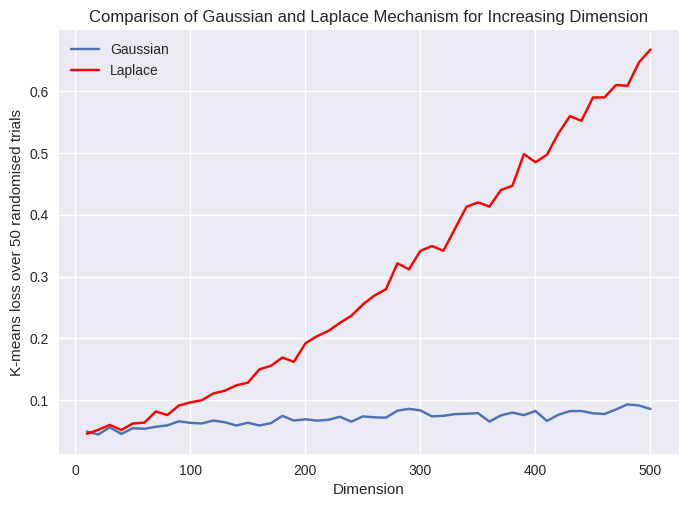

In [3]:
import matplotlib.pyplot as plt

plt.plot(dimensions, r_gaussian, label="Gaussian")
plt.plot(dimensions, r_laplace, label="Laplace", c="red")
plt.legend()
plt.xlabel("Dimension")
plt.ylabel("K-means loss over 50 randomised trials")
plt.title("Comparison of Gaussian and Laplace Mechanism for Increasing Dimension")